In [172]:
import pandas as pd 
from scipy import stats
from datetime import datetime
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pandas.tseries.offsets import MonthEnd
import statsmodels.api as sm
from IPython.display import display
import seaborn as sns 

## **Load data**

In [173]:
world_indices_raw = pd.read_csv("Data/world_indices.csv")
crsp_us = pd.read_csv("Data/crsp_us.csv")
df_fred = pd.read_csv("Data/fred_series.csv")

world_indices_raw["date"] = pd.to_datetime(world_indices_raw["date"]) + MonthEnd(0)
df_fred["DATE"] = pd.to_datetime(df_fred["DATE"]) + MonthEnd(0)
crsp_us["date"] = pd.to_datetime(crsp_us["date"]) + MonthEnd(0)

In [174]:
world_indices = world_indices_raw.pivot(index="date", columns="country", values="mportret")

rename_map = {
    'AUSTRALIA': 'AUS',
    'FRANCE': 'FRA',
    'GERMANY': 'DEU',
    'JAPAN': 'JPN',
    'SWITZERLAND': 'CHE',
    'UNITED KINGDOM': 'GBR'
}
world_indices = world_indices.rename(columns=rename_map)

In [175]:
#crsp_us["date"] = pd.to_datetime(crsp_us["date"])
crsp_us = crsp_us.set_index("date").loc["2002-01-01":"2024-12-31"]
crsp_us = crsp_us.rename(columns={"ret_us": "USA"})

# Merge to add USA
world_indices = world_indices.merge(crsp_us, left_index=True, right_index=True, how="left")

In [176]:
df_fred = df_fred.rename(columns={
    'AUDUSD': 'AUD_USD_fx',
    'EURUSD': 'EUR_USD_fx',
    'JPYUSD': 'JPY_USD_fx',
    'CHFUSD': 'CHF_USD_fx',
    'GBPUSD': 'GBP_USD_fx',
    'AUS_3M_IB': 'AUD_3M_rate',
    'FRA_3M_IB': 'FRA_3M_rate',
    'JPN_3M_IB': 'JPN_3M_rate',
    'CHE_3M_IB': 'CHE_3M_rate',
    'GBR_3M_IB': 'GBR_3M_rate',
    'USA_3M_IB': 'USD_3M_rate',
    'DEU_3M_IB': 'DEU_3M_rate',
    'DATE': 'date'
})

#df_fred["date"] = pd.to_datetime(df_fred["date"])
df_fred = df_fred.set_index("date")

df_fred = df_fred.loc["2002-01-01":"2024-12-31"]

foreign_currencies = ['AUD', 'EUR', 'JPY', 'CHF', 'GBP']
country_codes = ['AUD', 'FRA', 'DEU', 'JPN', 'CHE', 'GBR']

currency_map = {
    'AUS': 'AUD',
    'FRA': 'EUR',
    'DEU': 'EUR',
    'JPN': 'JPY',
    'CHE': 'CHF',
    'GBR': 'GBP'
}

In [177]:

#we fill 4 missing values in df_fred
df_fred = df_fred.fillna(method='ffill').fillna(method='bfill')
# We check if there are still missing values
if df_fred.isna().sum().sum() > 0:
    print("Il reste des valeurs manquantes dans le DataFrame.")
else:
    print("Aucune valeur manquante dans le DataFrame.")

Aucune valeur manquante dans le DataFrame.


/var/folders/tv/ylm92w4s43l8tcx370sxw2qr0000gn/T/ipykernel_47230/3694132430.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_fred = df_fred.fillna(method='ffill').fillna(method='bfill')


## **Functions**

In [178]:
def compute_unhedged_returns(world_indices, df_fred):
    # Initialize DataFrame for USD returns
    returns = pd.DataFrame(index=world_indices.index, columns=countries)
    returns['USA'] = world_indices['USA']

    # Compute USD returns for each foreign country
    for country in foreign_countries:
        currency = country_currency_map[country]
        fx_col = f"{currency}_USD_fx"

        # Align FX series with index data
        full_index = world_indices.index.union(df_fred.index).sort_values()
        fx_series = df_fred[fx_col].reindex(full_index)
        fx_growth = fx_series / fx_series.shift(1)
        fx_growth = fx_growth.reindex(world_indices.index)

        # Convert local return to USD return using FX variation
        returns[country] = (1 + world_indices[country]) * fx_growth - 1

    return returns.dropna()

In [179]:
currency_to_index = {
    "EUR": ["FRA", "DEU"],
    "AUD": ["AUS"],
    "JPY": ["JPN"],
    "CHF": ["CHE"],
    "GBP": ["GBR"]
}

def compute_hedged_returns(unhedged_returns, excess_ret):
    hedged = unhedged_returns.copy()

    # Subtract excess currency returns to get hedged returns
    for curr, indices in currency_to_index.items():
        for idx in indices:
            if idx in hedged.columns:
                hedged[idx] = unhedged_returns[idx] - excess_ret[curr]

    return hedged.dropna()

In [180]:
def excess_return_currency(df_fred):
    # Map currencies to local short-term interest rates
    currency_to_rate = {
        'AUD': 'AUD_3M_rate',
        'EUR': 'FRA_3M_rate', 
        'JPY': 'JPN_3M_rate',
        'CHF': 'CHE_3M_rate',
        'GBP': 'GBR_3M_rate'
    }

    excess_ret = pd.DataFrame(index=df_fred.index)

    # Compute USD excess return for each currency
    for curr, rate_col in currency_to_rate.items():
        fx_col = f"{curr}_USD_fx"
        fx_t = df_fred[fx_col]
        fx_t1 = fx_t.shift(-1)

        # Convert annual rates to monthly decimals
        r_foreign = df_fred[rate_col] / 1200
        r_us = df_fred["USD_3M_rate"] / 1200  # Use 3M rate to match foreign 3M rates (for consistency in excess return)

        # Excess return = FX growth * local interest - USD interest
        excess_ret[curr] = (fx_t1 / fx_t) * (1 + r_foreign) - (1 + r_us)

    return excess_ret


In [181]:
def compute_stats(series: pd.Series) -> dict:
    mean = series.mean() * 12
    std = series.std() * np.sqrt(12)
    sharpe = mean / std if std != 0 else np.nan
    return {"Mean": mean, "Std Dev": std, "Sharpe": sharpe}

In [182]:
def compute_Z(row: pd.Series) -> float:
    N = len(row)
    centered = row - (N + 1) / 2
    return 2 / centered.abs().sum()

In [183]:
def get_weights(ranks: pd.DataFrame, min_currencies: int = 2) -> pd.DataFrame:
    # Compute cross-sectional long/short weights from ranks
    weights = pd.DataFrame(index=ranks.index, columns=ranks.columns)

    for date, row in ranks.iterrows():
        valid = row.dropna()
        if len(valid) < min_currencies:
            continue

        # Center ranks around 0
        centered = valid - (len(valid) + 1) / 2

        # Normalize long and short positions separately
        long_scale = 1 / centered[centered > 0].sum()    # Scale so long weights sum to +1
        short_scale = 1 / centered[centered < 0].abs().sum()  # Scale so short weights sum to -1

        w = centered.copy()
        w[w > 0] *= long_scale
        w[w < 0] *= short_scale

        weights.loc[date] = w

    return weights

In [184]:
def run_strategy_regressions(strategy_returns, div_returns):
    aligned = pd.concat([strategy_returns, div_returns], axis=1).dropna()

    strategy_clean = aligned.iloc[:, 0].astype(float)
    div_clean = aligned.iloc[:, 1].astype(float)

    X = sm.add_constant(div_clean)
    model = sm.OLS(strategy_clean, X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})

    print(f"\nRegression Results for {strategy_returns.columns[0]}:")
    print(model.summary())

    alpha = model.params[0]
    beta = model.params[1]
    pval_alpha = model.pvalues[0]
    pval_beta = model.pvalues[1]

    print("\nInterpretation:")

    # Alpha
    if pval_alpha < 0.05:
        print(f"- Significant alpha ({alpha:.4f}) suggests independent return source")
    else:
        print(f"- No significant alpha ({alpha:.4f})")

    # Beta
    if pval_beta < 0.05:
        print(f"- Significant beta ({beta:.4f}) indicates correlation with DIV")
    else:
        print(f"- Beta ({beta:.4f}) is not significant — no clear exposure to DIV")

    # R-squared
    print(f"- R-squared: {model.rsquared:.4f} suggests {'strong' if model.rsquared > 0.5 else 'weak'} relationship")

    # Conclusion
    if pval_alpha < 0.05 and alpha > 0:
        print("- CONCLUSION: Independent and potentially valuable addition to DIV portfolio")
    elif pval_beta >= 0.05:
        print("- CONCLUSION: Likely an orthogonal/diversifying return stream")
    else:
        print("- CONCLUSION: Limited diversification benefits or ambiguous relationship")

In [185]:
def plot_strategy_performance(strategy_name, strategy_returns):
    strategy_cum = (1 + strategy_returns.fillna(0)).cumprod()

    fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axs[0].plot(strategy_returns.index, strategy_returns, label="Monthly Return")
    axs[0].set_title(f"Monthly Returns of the {strategy_name} Strategy")
    axs[0].set_ylabel("Monthly Return")
    axs[0].grid(True)

    axs[1].plot(strategy_cum.index, strategy_cum, label="Cumulative Return", color="navy")
    axs[1].set_title(f"Cumulative Performance of the {strategy_name} Strategy")
    axs[1].set_ylabel("Cumulative Return")
    axs[1].set_xlabel("Year")
    axs[1].grid(True)
    axs[1].legend()

    axs[1].xaxis.set_major_locator(mdates.YearLocator())
    axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.savefig(f"{strategy_name.lower().replace(' ', '_')}_strategy_performance.pdf")
    plt.show()

In [186]:
def summarize_strategy(name, returns):
    ann_ret = returns.mean() * 12
    ann_vol = returns.std() * np.sqrt(12)
    sharpe  = ann_ret / ann_vol

    summary_df = pd.DataFrame({
        "Annualized Return": [ann_ret],
        "Annualized Volatility": [ann_vol],
        "Sharpe Ratio": [sharpe]
    }, index=[name])

    return summary_df.round(4)

In [187]:
def get_weights_rev(ranks: pd.DataFrame, min_currencies: int = 2) -> pd.DataFrame:
    weights = pd.DataFrame(index=ranks.index, columns=ranks.columns)
    
    for date, row in ranks.iterrows():
        valid = row.dropna()
        if len(valid) < min_currencies:
            continue
            
        # Center ranks and separate long/short
        centered = (len(valid) + 1) / 2 - valid
        long_scale = 1 / centered[centered > 0].sum()
        short_scale = 1 / centered[centered < 0].abs().sum()
        
        # Apply separate scaling
        w = centered.copy()
        w[w > 0] *= long_scale
        w[w < 0] *= short_scale
        weights.loc[date] = w
        
    return weights

## **Part 3: DIV Strategy**

In [188]:
countries = ['AUS', 'FRA', 'DEU', 'JPN', 'CHE', 'GBR', 'USA']
foreign_countries = ['AUS', 'FRA', 'DEU', 'JPN', 'CHE', 'GBR']
currencies = ['AUD', 'EUR', 'JPY', 'CHF', 'GBP']

country_currency_map = {
    'AUS': 'AUD',
    'FRA': 'EUR',
    'DEU': 'EUR',
    'JPN': 'JPY',
    'CHE': 'CHF',
    'GBR': 'GBP'
}

In [189]:
def equal_weight_returns(returns):
    # Compute average return across available countries (ignores NaNs)
    return returns.sum(axis=1) / returns.notna().sum(axis=1)


def risk_parity_weights(returns, window=60):
    # Initialize weights DataFrame
    weights = pd.DataFrame(index=returns.index, columns=returns.columns)

    for i in range(window, len(returns)):
        # Compute volatilities over the past window
        vol = returns.iloc[i - window:i].std()

        # Compute inverse vol weights (lower vol = higher weight)
        inv_vol = 1 / vol
        weights.iloc[i] = inv_vol / inv_vol.sum()  # Normalize to sum to 1

    return weights


def mean_variance_weights(returns, window=60, shrinkage=0.1):
    # Initialize output DataFrames
    weights = pd.DataFrame(index=returns.index, columns=returns.columns)
    rf_weights = pd.Series(0.0, index=returns.index)  # always zero, we don’t use cash

    for t in range(window, len(returns)):
        # Select rolling window of past returns
        sample = returns.iloc[t - window:t]

        # Skip window if any NaN present
        if sample.isnull().values.any():
            continue

        # Compute expected returns and covariance matrix
        mu = sample.mean().values.reshape(-1, 1)
        cov = sample.cov().values

        # Apply shrinkage to covariance matrix
        d = len(returns.columns)
        cov_shrunk = (1 - shrinkage) * cov + shrinkage * np.trace(cov) / d * np.eye(d)

        try:
            # Compute mean-variance optimal weights (unconstrained)
            w_raw = np.linalg.inv(cov_shrunk) @ mu
            w = w_raw / w_raw.sum()  # normalize to sum to 1

            # Flatten and apply constraints: no shorting, full investment
            w = w.flatten()
            w = np.clip(w, 0, 1)       # long-only constraint
            w = w / w.sum()            # re-normalize after clipping

            weights.iloc[t] = w
        except:
            continue  # skip if matrix is singular or optimization fails

    return weights, rf_weights

In [190]:
def div_strategy(world_indices, df_fred, window=60):
    excess_ret = excess_return_currency(df_fred)
    unhedged_returns = compute_unhedged_returns(world_indices, df_fred)
    hedged_returns = compute_hedged_returns(unhedged_returns, excess_ret)
    
    results = {}
    
    # Only use foreign countries (exclude USA)
    foreign_countries = ['AUS', 'FRA', 'DEU', 'JPN', 'CHE', 'GBR']

    for name, returns in [('Unhedged', unhedged_returns), ('Hedged', hedged_returns)]:
        returns = returns.copy()
        
        # Use ONLY foreign countries for DIV strategies
        returns_foreign = returns[foreign_countries]
        
        # Equal Weight
        ew_ret = equal_weight_returns(returns_foreign)
        
        # Risk Parity
        rp_weights = risk_parity_weights(returns_foreign, window)
        rp_weights_shifted = rp_weights.shift(1)
        valid_idx = rp_weights_shifted.notna().any(axis=1)  # Don't require all 6 countries
        rp_ret = (rp_weights_shifted * returns_foreign).sum(axis=1)[valid_idx]

        # Align EW to same index as RP
        ew_ret = ew_ret.loc[rp_ret.index]
        
        # Mean-Variance (remove risk-free part - not needed)
        mv_weights, _ = mean_variance_weights(returns_foreign, window=60)
        mv_ret = (mv_weights.shift(1) * returns_foreign).sum(axis=1).dropna()
        
        # Store results
        results[name] = {
            'Equal Weight': ew_ret,
            'Risk Parity': rp_ret,
            'Mean Variance': mv_ret
        }
    
    div_returns = results['Hedged']['Risk Parity'].dropna()

    rp_hedged = results['Hedged']['Risk Parity'].dropna()
    rp_unhedged = results['Unhedged']['Risk Parity'].dropna()
    common_idx = rp_hedged.index.intersection(rp_unhedged.index)
    rp_hedged = rp_hedged.loc[common_idx]
    rp_unhedged = rp_unhedged.loc[common_idx]

    rp_hedged_stats = compute_stats(rp_hedged)
    rp_unhedged_stats = compute_stats(rp_unhedged)

    rp_comparison_df = pd.DataFrame({
        'Unhedged RP': rp_unhedged_stats,
        'Hedged RP': rp_hedged_stats
    })

    stats_results = {
        f"{hedge_type} {strategy}": compute_stats(ret.dropna())
        for hedge_type in results
        for strategy, ret in results[hedge_type].items()
    }

    stats_hedged = {k.replace("Hedged ", ""): v for k, v in stats_results.items() if k.startswith("Hedged")}
    stats_unhedged = {k.replace("Unhedged ", ""): v for k, v in stats_results.items() if k.startswith("Unhedged")}
    
    df_hedged = pd.DataFrame(stats_hedged).T
    df_unhedged = pd.DataFrame(stats_unhedged).T
    
    for df in [df_hedged, df_unhedged]:
        df.columns = ["Annual Return", "Volatility", "Sharpe Ratio"]
        df.index.name = "Strategy"
    
    df_hedged = df_hedged.astype(float).map("{:.4f}".format)
    df_unhedged = df_unhedged.astype(float).map("{:.4f}".format)
    
    print("Unhedged Strategies:")
    display(df_unhedged)
    
    print("Hedged Strategies:")
    display(df_hedged)

    return div_returns, results, stats_results, rp_comparison_df, unhedged_returns, hedged_returns

In [191]:
div_returns, div_all_results, div_stats, rp_compare, unhedged_returns, hedged_returns = div_strategy(world_indices, df_fred)

Unhedged Strategies:


,Annual Return,Volatility,Sharpe Ratio
Strategy,,,
Equal Weight,0.0613,0.1652,0.3711
Risk Parity,0.0592,0.1628,0.3638
Mean Variance,0.0471,0.1597,0.2948


Hedged Strategies:


,Annual Return,Volatility,Sharpe Ratio
Strategy,,,
Equal Weight,0.0724,0.1710,0.4232
Risk Parity,0.0715,0.1692,0.4225
Mean Variance,0.0421,0.1523,0.2762


/var/folders/tv/ylm92w4s43l8tcx370sxw2qr0000gn/T/ipykernel_47230/2266792327.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  strategy_cum = (1 + strategy_returns.fillna(0)).cumprod()


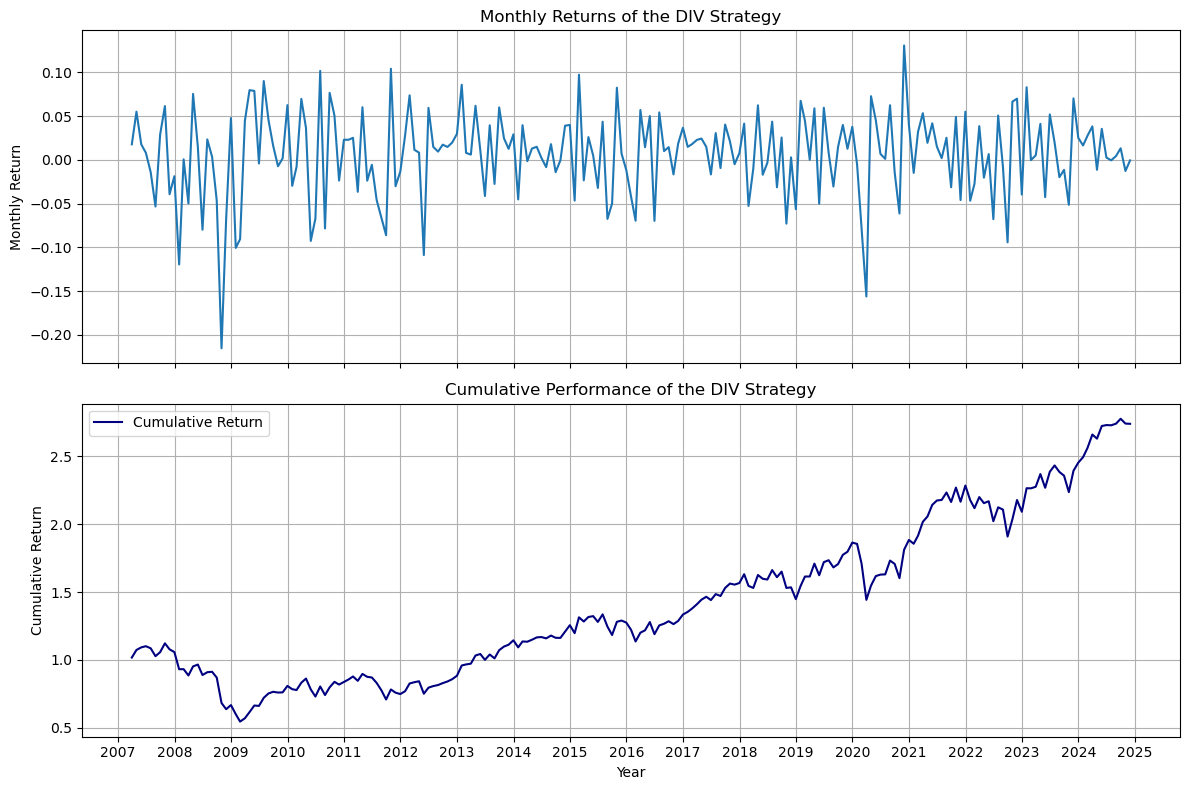

In [192]:
plot_strategy_performance("DIV", div_returns)
#plt.savefig("div_return.pdf")

In [193]:
summary = summarize_strategy("DIV (Hedged Risk Parity)", div_returns)
display(summary)

,Annualized Return,Annualized Volatility,Sharpe Ratio
DIV (Hedged Risk Parity),0.0715,0.1692,0.4225


## **Part 4: Equity Index Momentum Strategy (MOM)** 

4)a)

In [194]:
#We drop the USA column from hedged returns to focus on foreign returns
hedged_foreign_returns = hedged_returns.drop(columns=['USA'])

In [195]:
hedged_foreign_returns

,AUS,FRA,DEU,JPN,CHE,GBR
date,,,,,,
2002-02-28,-0.017453,-0.005094,-0.009540,0.052318,0.014218,-0.013159
2002-03-31,0.028028,0.025229,0.022458,0.076752,0.072344,0.023796
2002-04-30,-0.063177,-0.051554,-0.052631,0.023009,-0.007238,0.002395
2002-05-31,0.056556,-0.048521,-0.046121,0.037077,0.020468,-0.051895
2002-06-30,-0.002322,-0.025193,-0.012398,-0.113255,-0.120534,-0.070616
...,...,...,...,...,...,...
2024-07-31,-0.018631,-0.007471,-0.006376,-0.035396,0.026768,0.027131
2024-08-31,0.015993,0.033660,0.033464,-0.030587,-0.020857,0.011118
2024-09-30,0.115400,0.043776,0.061502,-0.092183,-0.038184,0.043534


In [196]:
country_codes = {
    "Australia": "AUS",
    "France": "FRA",
    "Germany": "DEU",
    "Japan": "JPN",
    "Switzerland": "CHE",
    "United Kingdom": "GBR",
}

#Now we calculate the 11-month cumulative return momentum signals (t−12 to t−1) for each month at date t of each country. Then we will rank them.

for country, code in country_codes.items():
    cum_ret = (1 + hedged_foreign_returns[code]).shift(1) #We shift by 1 to avoid look-ahead bias
    cum_ret = cum_ret.dropna()
    cum_ret_final = cum_ret.rolling(12).apply(np.prod, raw=True) - 1 #Calculate cumulative return from t-12 to t-1
    hedged_foreign_returns[f'mom_{code}'] = cum_ret_final 

hedged_foreign_returns

,AUS,FRA,DEU,JPN,CHE,GBR,mom_AUS,mom_FRA,mom_DEU,mom_JPN,mom_CHE,mom_GBR
date,,,,,,,,,,,,
2002-02-28,-0.017453,-0.005094,-0.009540,0.052318,0.014218,-0.013159,NaN,NaN,NaN,NaN,NaN,NaN
2002-03-31,0.028028,0.025229,0.022458,0.076752,0.072344,0.023796,NaN,NaN,NaN,NaN,NaN,NaN
2002-04-30,-0.063177,-0.051554,-0.052631,0.023009,-0.007238,0.002395,NaN,NaN,NaN,NaN,NaN,NaN
2002-05-31,0.056556,-0.048521,-0.046121,0.037077,0.020468,-0.051895,NaN,NaN,NaN,NaN,NaN,NaN
2002-06-30,-0.002322,-0.025193,-0.012398,-0.113255,-0.120534,-0.070616,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-31,-0.018631,-0.007471,-0.006376,-0.035396,0.026768,0.027131,0.155811,0.008452,0.090146,0.351957,0.091518,0.126731
2024-08-31,0.015993,0.033660,0.033464,-0.030587,-0.020857,0.011118,0.051220,-0.032778,0.032449,0.332830,0.167445,0.099690
2024-09-30,0.115400,0.043776,0.061502,-0.092183,-0.038184,0.043534,0.114591,0.022332,0.094217,0.281637,0.189338,0.112291


In [197]:
#We create the momentum signals DataFrame with the date and the momentum signals for each country
momentum_signals = hedged_foreign_returns.reset_index()[['date'] + [f'mom_{code}' for code in country_codes.values()]].copy()

#We drop rows with NaN values in momentum signals
momentum_signals = momentum_signals.dropna().reset_index(drop=True)

momentum_signals

,date,mom_AUS,mom_FRA,mom_DEU,mom_JPN,mom_CHE,mom_GBR
0,2003-02-28,-0.162457,-0.304424,-0.381465,-0.125010,-0.284685,-0.268895
1,2003-03-31,-0.161485,-0.343700,-0.414190,-0.181115,-0.336641,-0.275763
2,2003-04-30,-0.187708,-0.398174,-0.457466,-0.269586,-0.387332,-0.304260
3,2003-05-31,-0.098062,-0.309398,-0.344609,-0.270914,-0.283604,-0.251214
4,2003-06-30,-0.136466,-0.195780,-0.245668,-0.260990,-0.345260,-0.164196
...,...,...,...,...,...,...,...
257,2024-07-31,0.155811,0.008452,0.090146,0.351957,0.091518,0.126731
258,2024-08-31,0.051220,-0.032778,0.032449,0.332830,0.167445,0.099690
259,2024-09-30,0.114591,0.022332,0.094217,0.281637,0.189338,0.112291
260,2024-10-31,0.254015,0.134724,0.229597,0.138852,0.113825,0.170010


In [198]:
#Now we rank the momentum signals for each country. The highest momentum signal gets rank 6 and the lowest gets rank 1.
momentum_ranks = momentum_signals[[f'mom_{code}' for code in country_codes.values()]].rank(
    axis=1, method='first', ascending=True
)

momentum_ranks['date'] = momentum_signals['date']
momentum_ranks = momentum_ranks[['date'] + [col for col in momentum_ranks.columns if col != 'date']]
momentum_ranks.head(15)

,date,mom_AUS,mom_FRA,mom_DEU,mom_JPN,mom_CHE,mom_GBR
0,2003-02-28,5.0,2.0,1.0,6.0,3.0,4.0
1,2003-03-31,6.0,2.0,1.0,5.0,3.0,4.0
2,2003-04-30,6.0,2.0,1.0,5.0,3.0,4.0
3,2003-05-31,6.0,2.0,1.0,4.0,3.0,5.0
4,2003-06-30,6.0,4.0,3.0,2.0,1.0,5.0
5,2003-07-31,6.0,3.0,2.0,4.0,1.0,5.0
6,2003-08-31,4.0,3.0,2.0,5.0,1.0,6.0
7,2003-09-30,3.0,2.0,1.0,6.0,5.0,4.0
8,2003-10-31,1.0,4.0,6.0,5.0,2.0,3.0
9,2003-11-30,3.0,1.0,4.0,6.0,5.0,2.0


In [199]:
#Now that we have the ranks, we can assign weights based on these ranks.

#We need to set the date as index for the momentum ranks DataFrame
momentum_ranks_clean = momentum_ranks.set_index('date')

ranks = momentum_signals[[f'mom_{code}' for code in country_codes.values()]].rank(axis=1, method='first', ascending=True)
ranks.index = momentum_signals['date']

mom_weights_df = get_weights(ranks, min_currencies=2)
mom_weights_df.head(15)

,mom_AUS,mom_FRA,mom_DEU,mom_JPN,mom_CHE,mom_GBR
date,,,,,,
2003-02-28,0.333333,-0.333333,-0.555556,0.555556,-0.111111,0.111111
2003-03-31,0.555556,-0.333333,-0.555556,0.333333,-0.111111,0.111111
2003-04-30,0.555556,-0.333333,-0.555556,0.333333,-0.111111,0.111111
2003-05-31,0.555556,-0.333333,-0.555556,0.111111,-0.111111,0.333333
2003-06-30,0.555556,0.111111,-0.111111,-0.333333,-0.555556,0.333333
2003-07-31,0.555556,-0.111111,-0.333333,0.111111,-0.555556,0.333333
2003-08-31,0.111111,-0.111111,-0.333333,0.333333,-0.555556,0.555556
2003-09-30,-0.111111,-0.333333,-0.555556,0.555556,0.333333,0.111111
2003-10-31,-0.555556,0.111111,0.555556,0.333333,-0.333333,-0.111111


In [200]:
pays = ['AUS', 'FRA', 'DEU', 'JPN', 'CHE', 'GBR']
hedged_foreign_returns_cleaned = hedged_foreign_returns[pays].copy()

hedged_foreign_returns_cleaned.head(5)

,AUS,FRA,DEU,JPN,CHE,GBR
date,,,,,,
2002-02-28,-0.017453,-0.005094,-0.009540,0.052318,0.014218,-0.013159
2002-03-31,0.028028,0.025229,0.022458,0.076752,0.072344,0.023796
2002-04-30,-0.063177,-0.051554,-0.052631,0.023009,-0.007238,0.002395
2002-05-31,0.056556,-0.048521,-0.046121,0.037077,0.020468,-0.051895
2002-06-30,-0.002322,-0.025193,-0.012398,-0.113255,-0.120534,-0.070616


In [201]:
#We set the same names
mom_weights_df_cleaned = mom_weights_df.copy()
mom_weights_df_cleaned.columns = [col.replace("mom_", "") for col in mom_weights_df_cleaned.columns]


mom_weights_df_cleaned

,AUS,FRA,DEU,JPN,CHE,GBR
date,,,,,,
2003-02-28,0.333333,-0.333333,-0.555556,0.555556,-0.111111,0.111111
2003-03-31,0.555556,-0.333333,-0.555556,0.333333,-0.111111,0.111111
2003-04-30,0.555556,-0.333333,-0.555556,0.333333,-0.111111,0.111111
2003-05-31,0.555556,-0.333333,-0.555556,0.111111,-0.111111,0.333333
2003-06-30,0.555556,0.111111,-0.111111,-0.333333,-0.555556,0.333333
...,...,...,...,...,...,...
2024-07-31,0.333333,-0.555556,-0.333333,0.555556,-0.111111,0.111111
2024-08-31,-0.111111,-0.555556,-0.333333,0.555556,0.333333,0.111111
2024-09-30,0.111111,-0.555556,-0.333333,0.555556,0.333333,-0.111111


In [202]:
hedged_foreign_returns_cleaned_mom = hedged_foreign_returns_cleaned.copy()

In [203]:

#We shift the weights to multiply them by the return of the next month
shifted_weights_mom = mom_weights_df_cleaned.shift(1)

common_index = shifted_weights_mom.index.intersection(hedged_foreign_returns_cleaned_mom.index)

# We align the indices of both DataFrames to ensure they match
shifted_weights_mom = shifted_weights_mom.loc[common_index]
hedged_foreign_returns_cleaned_mom = hedged_foreign_returns_cleaned_mom.loc[common_index]


In [204]:
assert mom_weights_df_cleaned.index.equals(hedged_foreign_returns_cleaned_mom.index)


In [205]:
shifted_weights_mom

,AUS,FRA,DEU,JPN,CHE,GBR
date,,,,,,
2003-02-28,None,None,None,None,None,None
2003-03-31,0.333333,-0.333333,-0.555556,0.555556,-0.111111,0.111111
2003-04-30,0.555556,-0.333333,-0.555556,0.333333,-0.111111,0.111111
2003-05-31,0.555556,-0.333333,-0.555556,0.333333,-0.111111,0.111111
2003-06-30,0.555556,-0.333333,-0.555556,0.111111,-0.111111,0.333333
...,...,...,...,...,...,...
2024-07-31,-0.333333,-0.111111,0.111111,0.555556,-0.555556,0.333333
2024-08-31,0.333333,-0.555556,-0.333333,0.555556,-0.111111,0.111111
2024-09-30,-0.111111,-0.555556,-0.333333,0.555556,0.333333,0.111111


In [206]:

# Now we can calculate the long and short legs of the momentum strategy
long_leg_mom = (shifted_weights_mom.where(shifted_weights_mom > 0, 0) * hedged_foreign_returns_cleaned_mom).sum(axis=1)
short_leg_mom = (shifted_weights_mom.where(shifted_weights_mom < 0, 0) * hedged_foreign_returns_cleaned_mom).sum(axis=1)

In [207]:
hedged_foreign_returns_cleaned_mom

,AUS,FRA,DEU,JPN,CHE,GBR
date,,,,,,
2003-02-28,-0.016314,-0.061272,-0.061944,-0.015158,-0.059447,-0.022429
2003-03-31,-0.004122,-0.059866,-0.053074,-0.039578,-0.009600,-0.016489
2003-04-30,0.040213,0.088353,0.144439,0.021149,0.160842,0.078821
2003-05-31,0.011569,0.108017,0.097882,0.051193,-0.067359,0.058287
2003-06-30,0.082387,0.033569,0.066017,0.077075,0.060004,0.036121
...,...,...,...,...,...,...
2024-07-31,-0.018631,-0.007471,-0.006376,-0.035396,0.026768,0.027131
2024-08-31,0.015993,0.033660,0.033464,-0.030587,-0.020857,0.011118
2024-09-30,0.115400,0.043776,0.061502,-0.092183,-0.038184,0.043534


In [208]:
long_leg_mom

date
2003-02-28        -0.0
2003-03-31   -0.025194
2003-04-30    0.038148
2003-05-31    0.029968
2003-06-30    0.066375
                ...   
2024-07-31   -0.011329
2024-08-31   -0.010426
2024-09-30   -0.059104
2024-10-31    0.039356
2024-11-30    0.051177
Length: 262, dtype: object

In [209]:
#We delete the first row because it contains 0 due to the shift operation
long_leg_mom = long_leg_mom.iloc[1:]

long_leg_mom

date
2003-03-31   -0.025194
2003-04-30    0.038148
2003-05-31    0.029968
2003-06-30    0.066375
2003-07-31    0.008603
                ...   
2024-07-31   -0.011329
2024-08-31   -0.010426
2024-09-30   -0.059104
2024-10-31    0.039356
2024-11-30    0.051177
Length: 261, dtype: object

In [210]:
short_leg_mom

date
2003-02-28        -0.0
2003-03-31    0.050508
2003-04-30   -0.127566
2003-05-31     -0.0829
2003-06-30   -0.054533
                ...   
2024-07-31   -0.007831
2024-08-31   -0.027537
2024-09-30   -0.057643
2024-10-31    0.036208
2024-11-30    0.019195
Length: 262, dtype: object

In [211]:
#We delete the first row because it contains 0 due to the shift operation
short_leg_mom = short_leg_mom.iloc[1:]

short_leg_mom

date
2003-03-31    0.050508
2003-04-30   -0.127566
2003-05-31     -0.0829
2003-06-30   -0.054533
2003-07-31   -0.057746
                ...   
2024-07-31   -0.007831
2024-08-31   -0.027537
2024-09-30   -0.057643
2024-10-31    0.036208
2024-11-30    0.019195
Length: 261, dtype: object

In [212]:
mom_returns = (long_leg_mom + short_leg_mom).astype(float)

In [213]:
stats_df = pd.DataFrame({
    "Long": compute_stats(long_leg_mom),
    "Short": compute_stats(short_leg_mom),
    "MOM": compute_stats(mom_returns)
}).T

#We compute t-statistic and p-value for the MOM strategy
from scipy import stats
t_stat, p_value = stats.ttest_1samp(mom_returns.dropna(), 0)

print("Statistiques de performance :")
print(stats_df.round(4))

print("Test t sur le rendement moyen de MOM :")
print(f"t-stat = {t_stat:.2f}, p-value = {p_value:.4f}")

Statistiques de performance :
         Mean  Std Dev  Sharpe
Long   0.0944   0.1849  0.5106
Short -0.1144   0.1738 -0.6582
MOM   -0.0200   0.1657 -0.1205
Test t sur le rendement moyen de MOM :
t-stat = -0.56, p-value = 0.5747


Verifications

In [214]:
mom_weights_df_cleaned.apply(lambda row: row[row > 0].sum(), axis=1)  # should be ≈ 1.0

date
2003-02-28    1.0
2003-03-31    1.0
2003-04-30    1.0
2003-05-31    1.0
2003-06-30    1.0
             ... 
2024-07-31    1.0
2024-08-31    1.0
2024-09-30    1.0
2024-10-31    1.0
2024-11-30    1.0
Length: 262, dtype: float64

In [215]:
mom_weights_df_cleaned.apply(lambda row: row[row < 0].sum(), axis=1)  # should be ≈ 1.0

date
2003-02-28   -1.0
2003-03-31   -1.0
2003-04-30   -1.0
2003-05-31   -1.0
2003-06-30   -1.0
             ... 
2024-07-31   -1.0
2024-08-31   -1.0
2024-09-30   -1.0
2024-10-31   -1.0
2024-11-30   -1.0
Length: 262, dtype: float64

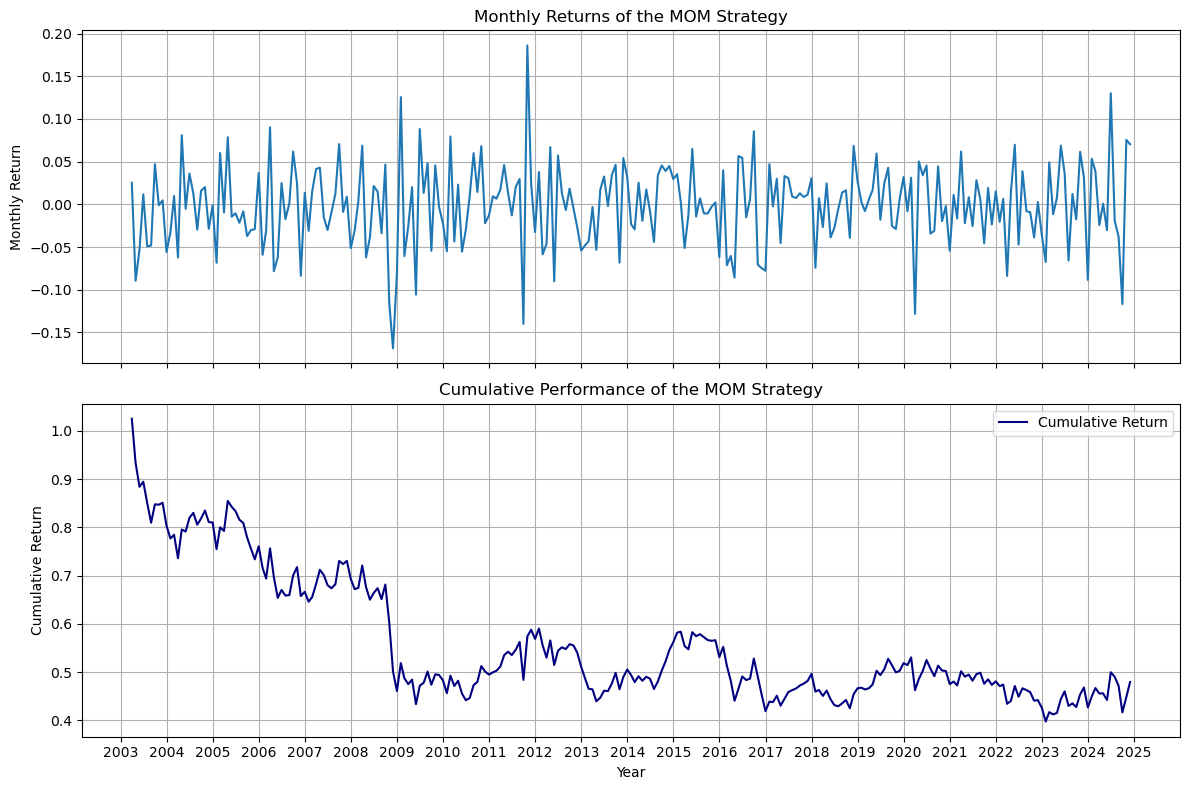

In [216]:
plot_strategy_performance("MOM", mom_returns)

In [217]:
print("\n" + "="*50)
print("MOM vs DIV Regression")
print("="*50)
run_strategy_regressions(mom_returns.to_frame("MOM"), div_returns.to_frame("DIV"))


MOM vs DIV Regression

Regression Results for MOM:
                            OLS Regression Results                            
Dep. Variable:                    MOM   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     2.054
Date:                Sun, 15 Jun 2025   Prob (F-statistic):              0.153
Time:                        23:42:53   Log-Likelihood:                 343.86
No. Observations:                 213   AIC:                            -683.7
Df Residuals:                     211   BIC:                            -677.0
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------


/var/folders/tv/ylm92w4s43l8tcx370sxw2qr0000gn/T/ipykernel_47230/3111963152.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = model.params[0]
/var/folders/tv/ylm92w4s43l8tcx370sxw2qr0000gn/T/ipykernel_47230/3111963152.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]
/var/folders/tv/ylm92w4s43l8tcx370sxw2qr0000gn/T/ipykernel_47230/3111963152.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pv

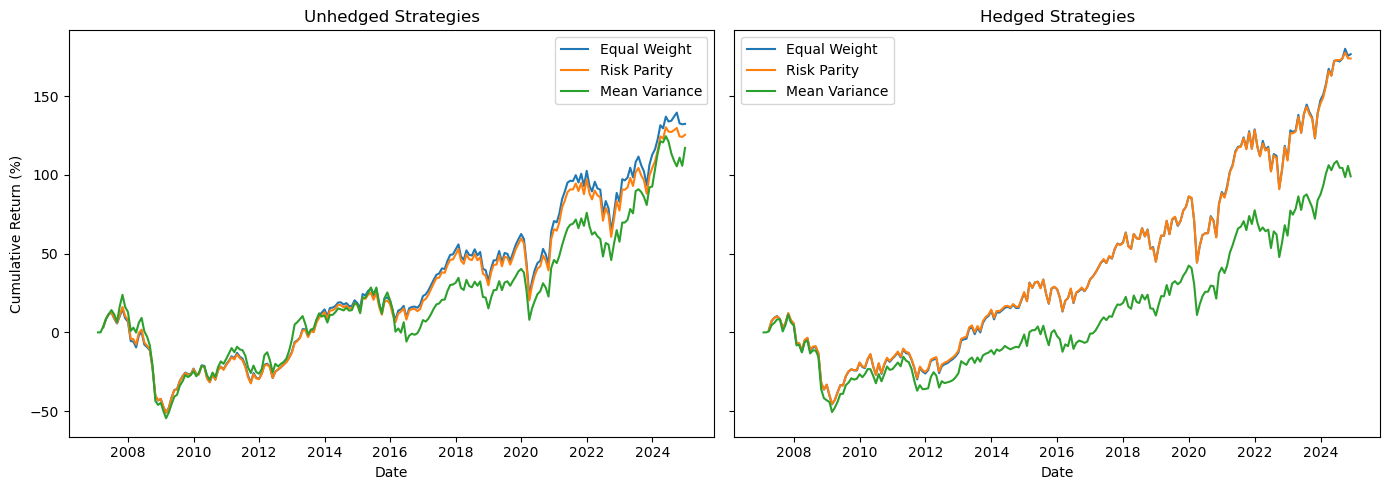

In [263]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left panel: Unhedged
for label, series in div_all_results['Unhedged'].items():
    series = series.dropna().loc["2007":]  # restrict to 2007 onward
    cumulative = (1 + series).cumprod() - 1
    axes[0].plot(cumulative * 100, label=label)

axes[0].set_title("Unhedged Strategies")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Cumulative Return (%)")
axes[0].legend()

# Right panel: Hedged
for label, series in div_all_results['Hedged'].items():
    series = series.dropna().loc["2007":]
    cumulative = (1 + series).cumprod() - 1
    axes[1].plot(cumulative * 100, label=label)

axes[1].set_title("Hedged Strategies")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.savefig("DIV_hedged_vs_unhedged.pdf", format="pdf", bbox_inches="tight")
plt.show()

## **Part 5: Equity Index Long Term Reversal Strategy (REV)** 

In [218]:
rev_signals = pd.DataFrame(index=hedged_foreign_returns_cleaned.index, columns=hedged_foreign_returns_cleaned.columns)

#We compute the t-60 to t-12 cumulative returns for each country
for country, code in country_codes.items():
    cum_ret_rev = (1 + hedged_foreign_returns_cleaned[code]).shift(12)
    cum_ret_rev_final = cum_ret_rev.rolling(49).apply(np.prod, raw=True) - 1

    rev_signals [code] = cum_ret_rev_final

rev_signals


,AUS,FRA,DEU,JPN,CHE,GBR
date,,,,,,
2002-02-28,NaN,NaN,NaN,NaN,NaN,NaN
2002-03-31,NaN,NaN,NaN,NaN,NaN,NaN
2002-04-30,NaN,NaN,NaN,NaN,NaN,NaN
2002-05-31,NaN,NaN,NaN,NaN,NaN,NaN
2002-06-30,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2024-07-31,0.283981,0.609312,0.368292,0.669676,0.296515,0.109857
2024-08-31,0.185937,0.587091,0.360289,0.617152,0.214517,0.125550
2024-09-30,0.230646,0.504191,0.304980,0.771020,0.258372,0.174062


In [219]:
#We drop the NaN values from the rev_signals DataFrame
rev_signals = rev_signals.dropna()

In [220]:
rev_signals

,AUS,FRA,DEU,JPN,CHE,GBR
date,,,,,,
2007-02-28,0.542148,0.268293,0.237142,0.914959,0.381654,0.229224
2007-03-31,0.483605,0.303649,0.263695,0.997607,0.458485,0.219626
2007-04-30,0.584913,0.306018,0.277384,0.812346,0.351314,0.224758
2007-05-31,0.622747,0.353809,0.310981,0.581472,0.253929,0.213794
2007-06-30,0.492752,0.437907,0.364642,0.566470,0.231339,0.276243
...,...,...,...,...,...,...
2024-07-31,0.283981,0.609312,0.368292,0.669676,0.296515,0.109857
2024-08-31,0.185937,0.587091,0.360289,0.617152,0.214517,0.125550
2024-09-30,0.230646,0.504191,0.304980,0.771020,0.258372,0.174062


In [221]:
#Now we can construct the ranks for the reverse signals

rev_ranks = rev_signals.rank(axis=1, method='first', ascending=True)
rev_ranks

,AUS,FRA,DEU,JPN,CHE,GBR
date,,,,,,
2007-02-28,5.0,3.0,2.0,6.0,4.0,1.0
2007-03-31,5.0,3.0,2.0,6.0,4.0,1.0
2007-04-30,5.0,3.0,2.0,6.0,4.0,1.0
2007-05-31,6.0,4.0,3.0,5.0,2.0,1.0
2007-06-30,5.0,4.0,3.0,6.0,1.0,2.0
...,...,...,...,...,...,...
2024-07-31,2.0,5.0,4.0,6.0,3.0,1.0
2024-08-31,2.0,5.0,4.0,6.0,3.0,1.0
2024-09-30,2.0,5.0,4.0,6.0,3.0,1.0


In [222]:
#Now that we have the ranks, we can assign weights based on these ranks.

rev_weights_df = get_weights_rev(rev_ranks, min_currencies=2)
rev_weights_df

,AUS,FRA,DEU,JPN,CHE,GBR
date,,,,,,
2007-02-28,-0.333333,0.111111,0.333333,-0.555556,-0.111111,0.555556
2007-03-31,-0.333333,0.111111,0.333333,-0.555556,-0.111111,0.555556
2007-04-30,-0.333333,0.111111,0.333333,-0.555556,-0.111111,0.555556
2007-05-31,-0.555556,-0.111111,0.111111,-0.333333,0.333333,0.555556
2007-06-30,-0.333333,-0.111111,0.111111,-0.555556,0.555556,0.333333
...,...,...,...,...,...,...
2024-07-31,0.333333,-0.333333,-0.111111,-0.555556,0.111111,0.555556
2024-08-31,0.333333,-0.333333,-0.111111,-0.555556,0.111111,0.555556
2024-09-30,0.333333,-0.333333,-0.111111,-0.555556,0.111111,0.555556


In [223]:
#We shift the weights to multiply them by the return of the next month

shifted_weights_rev = rev_weights_df.shift(1)
shifted_weights_rev


,AUS,FRA,DEU,JPN,CHE,GBR
date,,,,,,
2007-02-28,None,None,None,None,None,None
2007-03-31,-0.333333,0.111111,0.333333,-0.555556,-0.111111,0.555556
2007-04-30,-0.333333,0.111111,0.333333,-0.555556,-0.111111,0.555556
2007-05-31,-0.333333,0.111111,0.333333,-0.555556,-0.111111,0.555556
2007-06-30,-0.555556,-0.111111,0.111111,-0.333333,0.333333,0.555556
...,...,...,...,...,...,...
2024-07-31,0.333333,-0.333333,-0.111111,-0.555556,0.111111,0.555556
2024-08-31,0.333333,-0.333333,-0.111111,-0.555556,0.111111,0.555556
2024-09-30,0.333333,-0.333333,-0.111111,-0.555556,0.111111,0.555556


In [224]:
hedged_foreign_returns_cleaned_rev = hedged_foreign_returns_cleaned.copy()

common_index = shifted_weights_rev.index.intersection(hedged_foreign_returns_cleaned_rev.index)

# We aligned the indices of both DataFrames to ensure they match
shifted_weights_rev = shifted_weights_rev.loc[common_index]
hedged_foreign_returns_cleaned_rev = hedged_foreign_returns_cleaned_rev.loc[common_index]

In [225]:

#Now we can calculate the long and short legs of the reverse strategy
long_leg_rev = (shifted_weights_rev.where(shifted_weights_rev > 0, 0) * hedged_foreign_returns_cleaned_rev).sum(axis=1)
short_leg_rev = (shifted_weights_rev.where(shifted_weights_rev < 0, 0) * hedged_foreign_returns_cleaned_rev).sum(axis=1)

In [226]:
long_leg_rev

date
2007-02-28         0.0
2007-03-31    0.021658
2007-04-30    0.067945
2007-05-31    0.013823
2007-06-30   -0.008934
                ...   
2024-07-31    0.011836
2024-08-31     0.00919
2024-09-30     0.05841
2024-10-31   -0.047903
2024-11-30    0.043205
Length: 214, dtype: object

In [227]:
#We delete the first row because it contains 0 due to the shift operation
long_leg_rev = long_leg_rev.iloc[1:]
long_leg_rev

date
2007-03-31    0.021658
2007-04-30    0.067945
2007-05-31    0.013823
2007-06-30   -0.008934
2007-07-31    -0.03572
                ...   
2024-07-31    0.011836
2024-08-31     0.00919
2024-09-30     0.05841
2024-10-31   -0.047903
2024-11-30    0.043205
Length: 213, dtype: object

In [228]:
short_leg_rev

date
2007-02-28         0.0
2007-03-31    0.003486
2007-04-30   -0.020792
2007-05-31   -0.023043
2007-06-30   -0.028356
                ...   
2024-07-31    0.022863
2024-08-31    0.002054
2024-09-30    0.029787
2024-10-31   -0.037136
2024-11-30    0.045022
Length: 214, dtype: object

In [229]:
#We delete the first line because it contains 0 due to the shift operation
short_leg_rev = short_leg_rev.iloc[1:]
short_leg_rev

date
2007-03-31    0.003486
2007-04-30   -0.020792
2007-05-31   -0.023043
2007-06-30   -0.028356
2007-07-31    0.011242
                ...   
2024-07-31    0.022863
2024-08-31    0.002054
2024-09-30    0.029787
2024-10-31   -0.037136
2024-11-30    0.045022
Length: 213, dtype: object

In [230]:
rev_returns = (long_leg_rev + short_leg_rev).astype(float)

In [231]:
rev_returns

date
2007-03-31    0.025143
2007-04-30    0.047153
2007-05-31   -0.009220
2007-06-30   -0.037290
2007-07-31   -0.024478
                ...   
2024-07-31    0.034700
2024-08-31    0.011245
2024-09-30    0.088197
2024-10-31   -0.085039
2024-11-30    0.088227
Length: 213, dtype: float64

In [232]:
def compute_stats_(series: pd.Series) -> dict:
    mean = series.mean()
    std = series.std(ddof=1)
    sharpe_annualized = (mean / std) * np.sqrt(12) if std > 0 else np.nan

    return {
         "Mean": mean,
        "Std Dev": std,
        "Annualized Sharpe": sharpe_annualized
    }

stats_df = pd.DataFrame({
    "Long": compute_stats_(long_leg_rev),
    "Short": compute_stats_(short_leg_rev),
    "REV": compute_stats_(rev_returns)
}).T

#Test t-statistic and p-value for the REV strategy
from scipy import stats
t_stat, p_value = stats.ttest_1samp(rev_returns.dropna(), 0)

print("Statistiques de performance :")
print(stats_df.round(4))

print("Test t sur le rendement moyen de REV :")
print(f"t-stat = {t_stat:.2f}, p-value = {p_value:.4f}")



Statistiques de performance :
         Mean  Std Dev  Annualized Sharpe
Long   0.0068   0.0541             0.4326
Short -0.0032   0.0549            -0.2033
REV    0.0035   0.0444             0.2753
Test t sur le rendement moyen de REV :
t-stat = 1.16, p-value = 0.2474


In [233]:
rev_weights_df.apply(lambda row: row[row > 0].sum(), axis=1)  # should be ≈ 1.0

date
2007-02-28    1.0
2007-03-31    1.0
2007-04-30    1.0
2007-05-31    1.0
2007-06-30    1.0
             ... 
2024-07-31    1.0
2024-08-31    1.0
2024-09-30    1.0
2024-10-31    1.0
2024-11-30    1.0
Length: 214, dtype: float64

In [234]:
rev_weights_df.apply(lambda row: row[row < 0].sum(), axis=1)  # should be ≈ 1.0

date
2007-02-28   -1.0
2007-03-31   -1.0
2007-04-30   -1.0
2007-05-31   -1.0
2007-06-30   -1.0
             ... 
2024-07-31   -1.0
2024-08-31   -1.0
2024-09-30   -1.0
2024-10-31   -1.0
2024-11-30   -1.0
Length: 214, dtype: float64

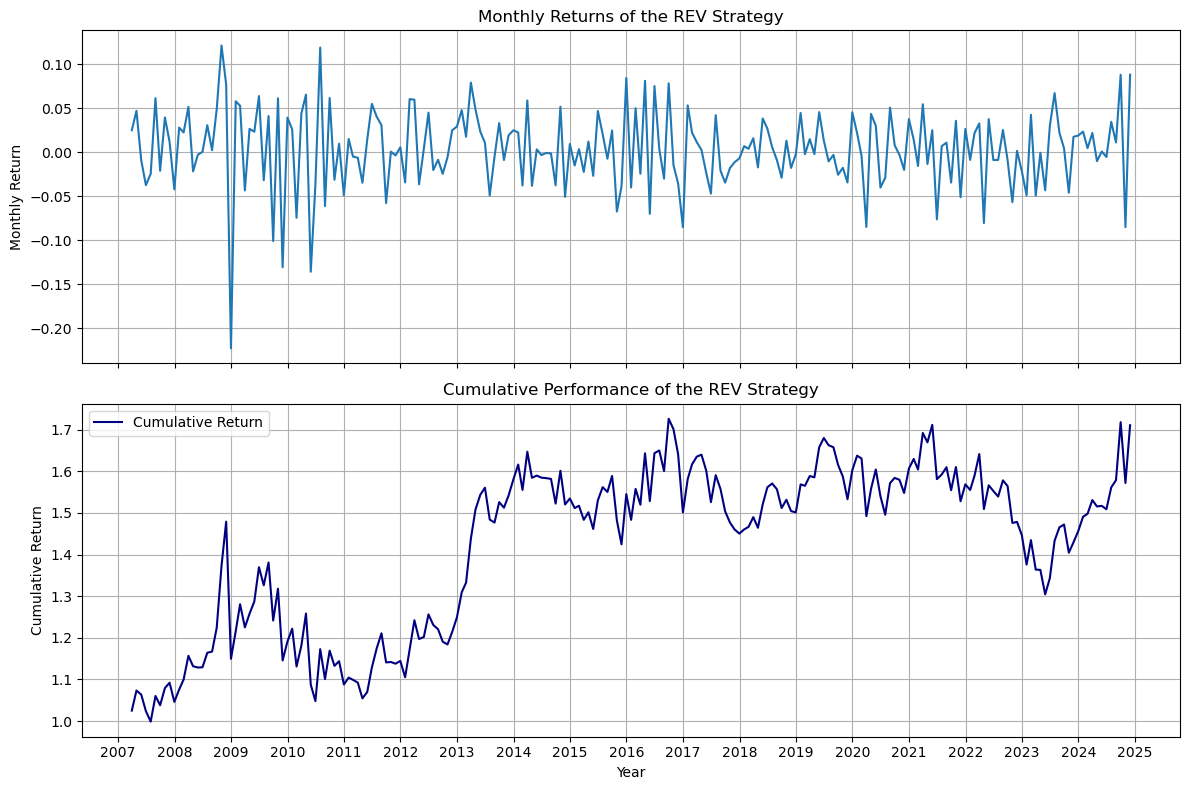

In [235]:
plot_strategy_performance("REV", rev_returns)

In [236]:
print("\n" + "="*50)
print("REV vs DIV Regression")
print("="*50)
run_strategy_regressions(rev_returns.to_frame("REV"), div_returns.to_frame("DIV"))


REV vs DIV Regression

Regression Results for REV:
                            OLS Regression Results                            
Dep. Variable:                    REV   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                  0.002664
Date:                Sun, 15 Jun 2025   Prob (F-statistic):              0.959
Time:                        23:42:59   Log-Likelihood:                 361.55
No. Observations:                 213   AIC:                            -719.1
Df Residuals:                     211   BIC:                            -712.4
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------


/var/folders/tv/ylm92w4s43l8tcx370sxw2qr0000gn/T/ipykernel_47230/3111963152.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = model.params[0]
/var/folders/tv/ylm92w4s43l8tcx370sxw2qr0000gn/T/ipykernel_47230/3111963152.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]
/var/folders/tv/ylm92w4s43l8tcx370sxw2qr0000gn/T/ipykernel_47230/3111963152.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pv

## **Part 6: CARRY Strategy** 

In [237]:
foreign_currencies = ['AUD', 'EUR', 'JPY', 'CHF', 'GBP']
country_codes = ['AUD', 'FRA', 'JPN', 'CHE', 'GBR']

In [238]:
def currency_carry_strategy(df_fred: pd.DataFrame, excess_ret: pd.DataFrame):
    # Get interest rate columns for all countries
    rate_cols = [f"{c}_3M_rate" for c in country_codes]

    # Compute interest rate differentials vs USD
    diff_rates = df_fred[rate_cols].sub(df_fred["USD_3M_rate"], axis=0)
    diff_rates.columns = foreign_currencies  # rename for ranking

    # Rank currencies by interest differential (ascending)
    ranks = diff_rates.rank(axis=1, method="first", ascending=True)

    # Compute long/short weights from ranks
    weights = get_weights(ranks)

    # Align excess returns with weights index
    excess_ret_aligned = excess_ret.reindex(weights.index)

    # Compute long and short legs separately
    long_ret = (weights[weights > 0] * excess_ret_aligned).sum(axis=1, skipna=True)
    short_ret = (weights[weights < 0] * excess_ret_aligned).sum(axis=1, skipna=True)

    # Total carry return = long + short
    carry_ret = (long_ret + short_ret).astype(float)

    # Compute performance stats by leg
    stats_df = pd.DataFrame({
        "Long": compute_stats(long_ret),
        "Short": compute_stats(short_ret),
        "Carry": compute_stats(carry_ret)
    }).T

    # Run t-test on mean return of strategy
    t_stat, p_value = stats.ttest_1samp(carry_ret.dropna(), 0)
    print(f"Carry mean t-stat={t_stat:.2f}, p-value={p_value:.3f}")

    # Shift weights for out-of-sample returns
    carry_ret = (weights.shift(1) * excess_ret_aligned).sum(axis=1)

    # Remove first and last row (=0 + for alignement)
    carry_ret = carry_ret.iloc[1:-1]

    return carry_ret, weights, stats_df

In [239]:
excess_ret = excess_return_currency(df_fred)
carry_returns, carry_weights, carry_stats = currency_carry_strategy(df_fred, excess_ret)

display(carry_stats)

Carry mean t-stat=1.92, p-value=0.056


,Mean,Std Dev,Sharpe
Long,0.022221,0.100026,0.222152
Short,0.037361,0.074621,0.500669
Carry,0.059582,0.149076,0.399672


In [240]:
styled_returns = (
    carry_returns
    .head()
    .to_frame("Carry Return")
    .style.format("{:.4%}")
    .set_caption("First 5 Monthly Returns of the Carry Strategy")
)
display(styled_returns)

,Carry Return
date,
2002-02-28 00:00:00,3.7679%
2002-03-31 00:00:00,4.8750%
2002-04-30 00:00:00,7.3690%
2002-05-31 00:00:00,5.3294%
2002-06-30 00:00:00,-0.7433%


In [241]:
styled_weights = (
    carry_weights
    .head()
    .style.format("{:+.2f}")
    .set_caption("First 5 Dates of Currency Weights")
)
display(styled_weights)

,AUD,EUR,JPY,CHF,GBP
date,,,,,
2002-01-31 00:00:00,+0.67,+0.00,-0.67,-0.33,+0.33
2002-02-28 00:00:00,+0.67,+0.00,-0.67,-0.33,+0.33
2002-03-31 00:00:00,+0.67,+0.00,-0.67,-0.33,+0.33
2002-04-30 00:00:00,+0.67,+0.00,-0.67,-0.33,+0.33
2002-05-31 00:00:00,+0.67,+0.00,-0.67,-0.33,+0.33


In [242]:
print("\n" + "="*50)
print("CARRY vs DIV Regression")
print("="*50)
run_strategy_regressions(carry_returns.to_frame("CARRY"), div_returns.to_frame("DIV"))


CARRY vs DIV Regression

Regression Results for CARRY:
                            OLS Regression Results                            
Dep. Variable:                  CARRY   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     7.503
Date:                Sun, 15 Jun 2025   Prob (F-statistic):            0.00669
Time:                        23:43:00   Log-Likelihood:                 371.65
No. Observations:                 213   AIC:                            -739.3
Df Residuals:                     211   BIC:                            -732.6
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

/var/folders/tv/ylm92w4s43l8tcx370sxw2qr0000gn/T/ipykernel_47230/3111963152.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = model.params[0]
/var/folders/tv/ylm92w4s43l8tcx370sxw2qr0000gn/T/ipykernel_47230/3111963152.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]
/var/folders/tv/ylm92w4s43l8tcx370sxw2qr0000gn/T/ipykernel_47230/3111963152.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pv

The regression confirms that our carry strategy offers independent performance from the DIV benchmark. The low R-squared and insignificant beta suggest that carry returns are not explained by global equity factor exposure, making it a potentially diversifying addition to a portfolio already invested in international equities.

**Verifications**

In [243]:
carry_weights.apply(lambda row: row[row > 0].sum(), axis=1).head(5)  # should be ≈ 1.0

date
2002-01-31    1.0
2002-02-28    1.0
2002-03-31    1.0
2002-04-30    1.0
2002-05-31    1.0
dtype: float64

In [244]:
carry_weights.apply(lambda row: row[row < 0].sum(), axis=1).head(5)  # should be ≈ -1.0

date
2002-01-31   -1.0
2002-02-28   -1.0
2002-03-31   -1.0
2002-04-30   -1.0
2002-05-31   -1.0
dtype: float64

In [245]:
# Check if the strategy is dollar neutral (sum of weights = 0 each month)
carry_weights.sum(axis=1).head(5)

date
2002-01-31    0.0
2002-02-28    0.0
2002-03-31    0.0
2002-04-30    0.0
2002-05-31    0.0
dtype: object

/var/folders/tv/ylm92w4s43l8tcx370sxw2qr0000gn/T/ipykernel_47230/2266792327.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  strategy_cum = (1 + strategy_returns.fillna(0)).cumprod()


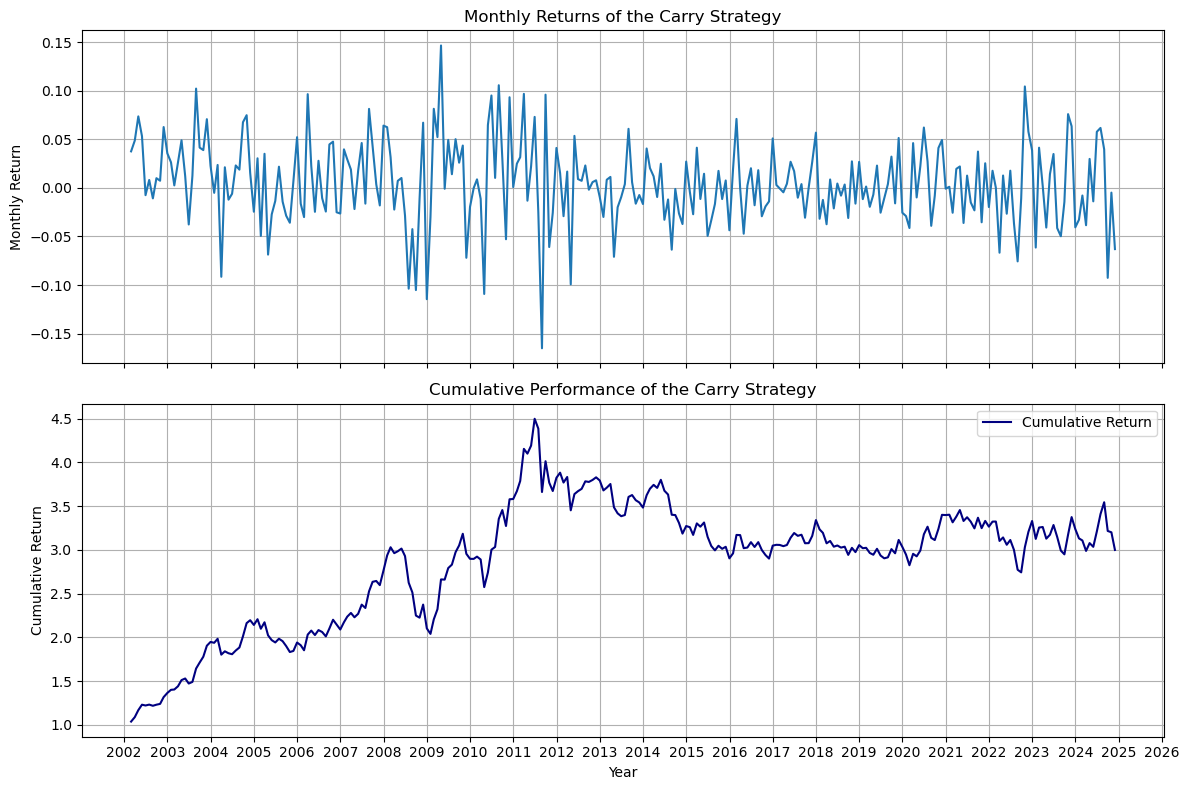

In [246]:
plot_strategy_performance("Carry", carry_returns)

In [247]:
carry_weights.loc["2008"].idxmax(axis=1)  # Which currency had largest long weight?
carry_weights.loc["2008"].idxmin(axis=1)  # Which currency was most short?

date
2008-01-31    JPY
2008-02-29    JPY
2008-03-31    JPY
2008-04-30    JPY
2008-05-31    JPY
2008-06-30    JPY
2008-07-31    JPY
2008-08-31    JPY
2008-09-30    JPY
2008-10-31    JPY
2008-11-30    CHF
2008-12-31    CHF
dtype: object

Due to interest rate differentials collapsing ahead of the GFC, the carry signal rotated into JPY and CHF by mid-2008. These currencies appreciated during the crisis, mitigating what would otherwise have been a classic carry drawdown.

Contrary to the traditional view of carry strategies suffering major losses during systemic crises, our implementation exhibits resilience in 2008. This is due to the signal rotating into JPY and CHF — two classic safe havens — in response to collapsing interest rate differentials. As a result, the carry portfolio avoided large drawdowns during the financial crisis and maintained a positive cumulative trajectory.

<Axes: xlabel='date'>

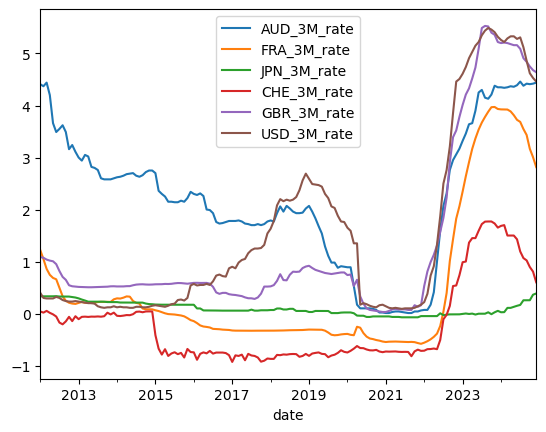

In [248]:
df_fred[[f"{c}_3M_rate" for c in country_codes] + ["USD_3M_rate"]].loc["2012":].plot()

## **Part 7: DOLLAR Strategy** 

In [249]:
def currency_dollar_strategy(df_fred: pd.DataFrame, excess_ret_currency: pd.DataFrame):
    # Number of foreign currencies
    N = len(foreign_currencies)

    # Align excess returns (not strictly used here)
    excess_ret_aligned = excess_ret_currency.shift(-1)

    # Compute average excess return vs foreign currencies (short USD)
    return_dollar = -(1 / N) * excess_ret_currency.sum(axis=1)

    # Align to carry strategy index (for later)
    return_dollar = return_dollar.reindex(carry_returns.index)

    # Compute performance stats
    stats_df = pd.DataFrame({
        "Dollar": compute_stats(return_dollar)
    }).T

    # Format stats for display
    styled_stats = (
        stats_df.style
        .format("{:.2%}", subset=["Mean", "Std Dev"])
        .format("{:.4f}", subset=["Sharpe"])
        .set_caption("Dollar Strategy Performance Statistics")
    )

    # T-test on average return
    t_stat, p_value = stats.ttest_1samp(return_dollar.dropna(), 0)
    print(f"T-test: t = {t_stat:.2f}, p = {p_value:.3f}")

    return return_dollar, styled_stats

In [250]:
return_dollar, dollar_stats = currency_dollar_strategy(df_fred, excess_ret)
display(dollar_stats)


T-test: t = 0.03, p = 0.973


,Mean,Std Dev,Sharpe
Dollar,0.03%,4.29%,0.0070


In [251]:
print("\n" + "="*50)
print("DOLLAR vs DIV Regression")
print("="*50)
run_strategy_regressions(return_dollar.to_frame("DOLLAR"), div_returns.to_frame("DIV"))


DOLLAR vs DIV Regression

Regression Results for DOLLAR:
                            OLS Regression Results                            
Dep. Variable:                 DOLLAR   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     7.629
Date:                Sun, 15 Jun 2025   Prob (F-statistic):            0.00625
Time:                        23:43:06   Log-Likelihood:                 623.61
No. Observations:                 213   AIC:                            -1243.
Df Residuals:                     211   BIC:                            -1236.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

/var/folders/tv/ylm92w4s43l8tcx370sxw2qr0000gn/T/ipykernel_47230/3111963152.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = model.params[0]
/var/folders/tv/ylm92w4s43l8tcx370sxw2qr0000gn/T/ipykernel_47230/3111963152.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]
/var/folders/tv/ylm92w4s43l8tcx370sxw2qr0000gn/T/ipykernel_47230/3111963152.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pv

**Verifications**

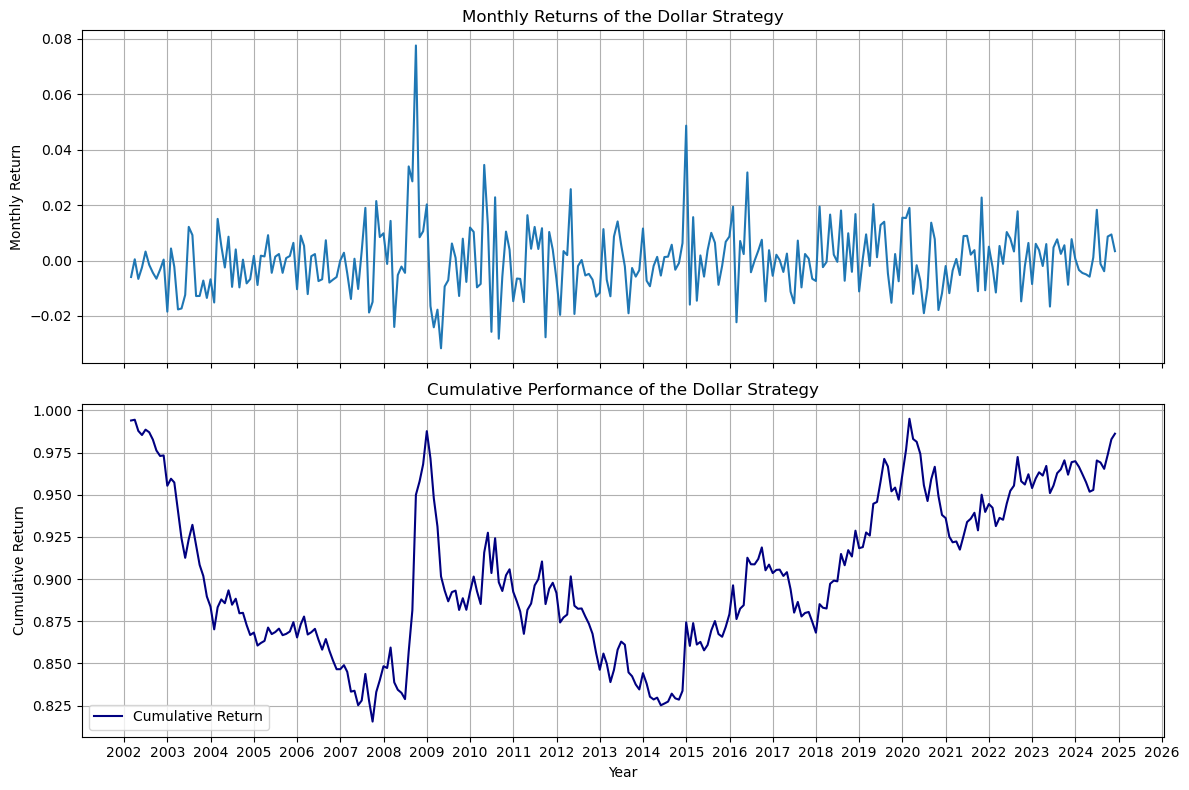

In [252]:
plot_strategy_performance("Dollar", return_dollar)

## **LENGHT OF STRATEGIES**

In [253]:
# Dictionary of all return series
strategy_series = {
    "DIV": div_returns,
    "Carry": carry_returns,
    "Dollar": return_dollar,
    "MOM": mom_returns,
    "REV": rev_returns
}

# Create summary
summary = []
for name, series in strategy_series.items():
    s = series.dropna()
    summary.append({
        "Strategy": name,
        "First Date": s.index[0],
        "First Return": s.iloc[0],
        "Last Date": s.index[-1],
        "Last Return": s.iloc[-1],
        "Length": len(s)
    })

# Convert to DataFrame
summary_df = pd.DataFrame(summary)
display(summary_df)

,Strategy,First Date,First Return,Last Date,Last Return,Length
0,DIV,2007-03-31,0.017671,2024-11-30,-0.000637,213
1,Carry,2002-02-28,0.037679,2024-11-30,-0.062987,274
2,Dollar,2002-02-28,-0.005955,2024-11-30,0.003374,274
3,MOM,2003-03-31,0.025314,2024-11-30,0.070372,261
4,REV,2007-03-31,0.025143,2024-11-30,0.088227,213


# **8. Optimal Fund Portfolio Return (STRAT)**

## Preparation of data 

In [254]:
#We make an array with all the returns we will use in this part (and cut it because Rrev has less values)

t_bill = df_fred['USD_1M_TB'] / 1200  # Convert annual % to monthly decimal
t_bill.index = pd.to_datetime(t_bill.index)
t_bill_returns = t_bill.reindex(rev_returns.index)

df_q8 = pd.concat([
    div_returns.rename("DIV"),
    carry_returns.rename("CARRY"),
    return_dollar.rename("DOLLAR"),
    mom_returns.rename("MOM"),
    rev_returns.rename("REV"),
    t_bill_returns.rename("T_BILL")  
], axis=1)
df_q8= df_q8.dropna() #drop na to keep only data after 2007 (where Rev is compute)
df_q8

,DIV,CARRY,DOLLAR,MOM,REV,T_BILL
date,,,,,,
2007-03-31,0.017671,0.018907,-0.013888,0.041340,0.025143,0.004225
2007-04-30,0.055004,-0.021717,0.000637,0.043069,0.047153,0.004000
2007-05-31,0.01767,0.017767,-0.010280,-0.015054,-0.009220,0.003983
2007-06-30,0.007953,0.046278,0.003377,-0.030077,-0.037290,0.003567
2007-07-31,-0.014123,-0.016152,0.019008,-0.009408,-0.024478,0.004275
...,...,...,...,...,...,...
2024-07-31,-0.000558,0.061816,-0.001222,-0.019160,0.034700,0.004575
2024-08-31,0.004329,0.039735,-0.003877,-0.037963,0.011245,0.004508
2024-09-30,0.013191,-0.092582,0.008651,-0.116747,0.088197,0.004108


# 8.1 

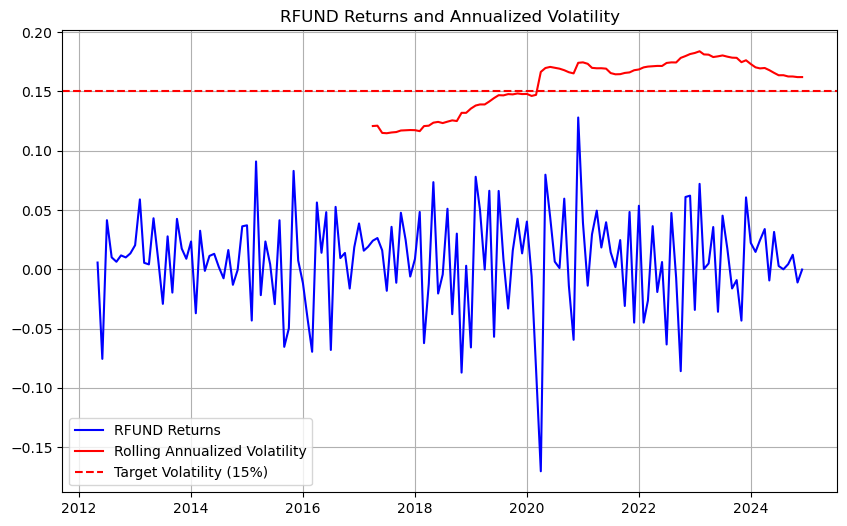

Mean a: 0.9492
Realized annualized volatility: 14.29%
Realized annualized return: 9.50%


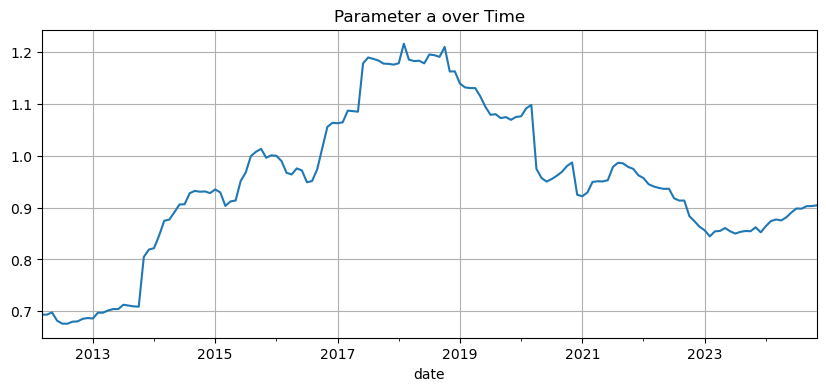

In [255]:
rolling_volatilities_DIV = (df_q8['DIV'] - df_q8['T_BILL']).shift(1).rolling(window=60, min_periods=60).std() # Calculate rolling volatility of DIV excess returns with a 60-month window
a = 0.15 / (rolling_volatilities_DIV * np.sqrt(12))
RFUND_q8_1 = df_q8['T_BILL'] + a.shift(1) * (df_q8['DIV'] - df_q8['T_BILL'])

rolling_vol_RFUND = RFUND_q8_1.rolling(window=60).std() * np.sqrt(12)

# Plot RFUND returns and its volatility
valid_index = rolling_volatilities_DIV.dropna().index
plt.figure(figsize=(10, 6))
plt.plot(RFUND_q8_1.loc[valid_index], label='RFUND Returns', color='blue')
plt.plot(rolling_vol_RFUND.loc[valid_index], label='Rolling Annualized Volatility', color='red')
plt.axhline(y=0.15, color='red', linestyle='--', label='Target Volatility (15%)')
plt.legend()
plt.title('RFUND Returns and Annualized Volatility')
plt.grid(True)
plt.show()

# Print statistics
print(f"Mean a: {a.loc[valid_index].mean():.4f}")
print(f"Realized annualized volatility: {RFUND_q8_1.loc[valid_index].std() * np.sqrt(12):.2%}")
print(f"Realized annualized return: {RFUND_q8_1.loc[valid_index].mean() * 12:.2%}")

# Plot 'a' over time
a.loc[valid_index].plot(title='Parameter a over Time', figsize=(10, 4), grid=True)
plt.show()

# 8.2 

Annualized volatility STRAT : 3.06%
Annualized return STRAT : 0.67%
MOM       0.141201
REV       0.160248
CARRY     0.178316
DOLLAR    0.520234
dtype: float64


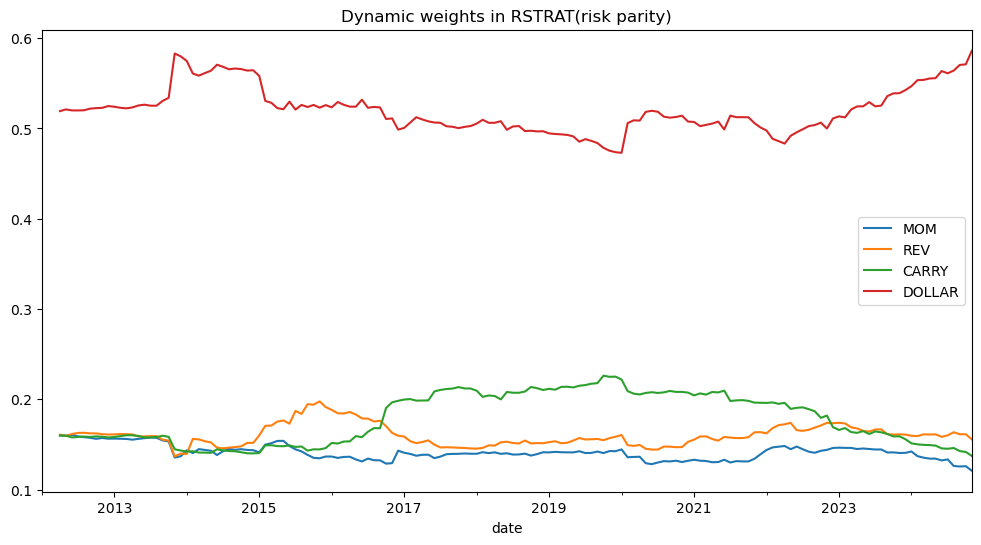

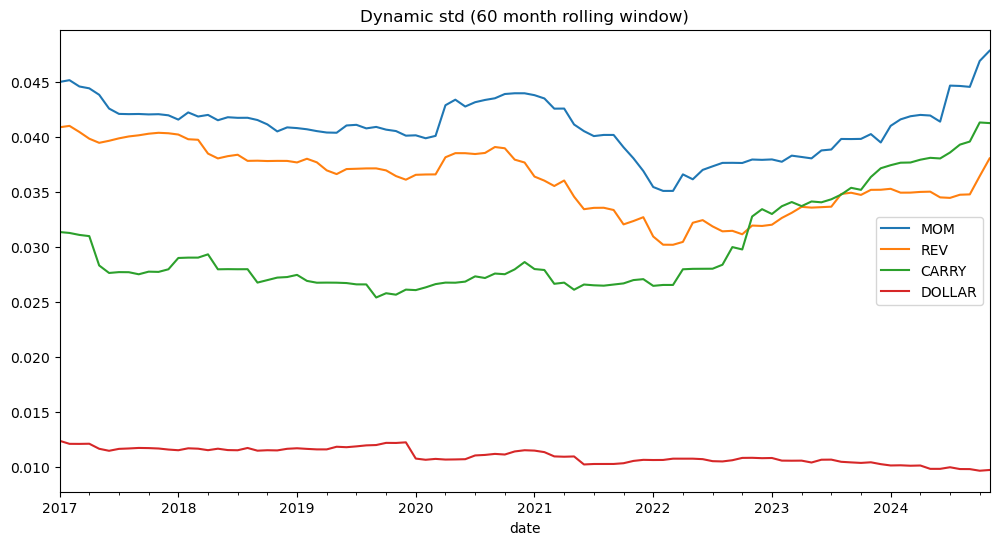

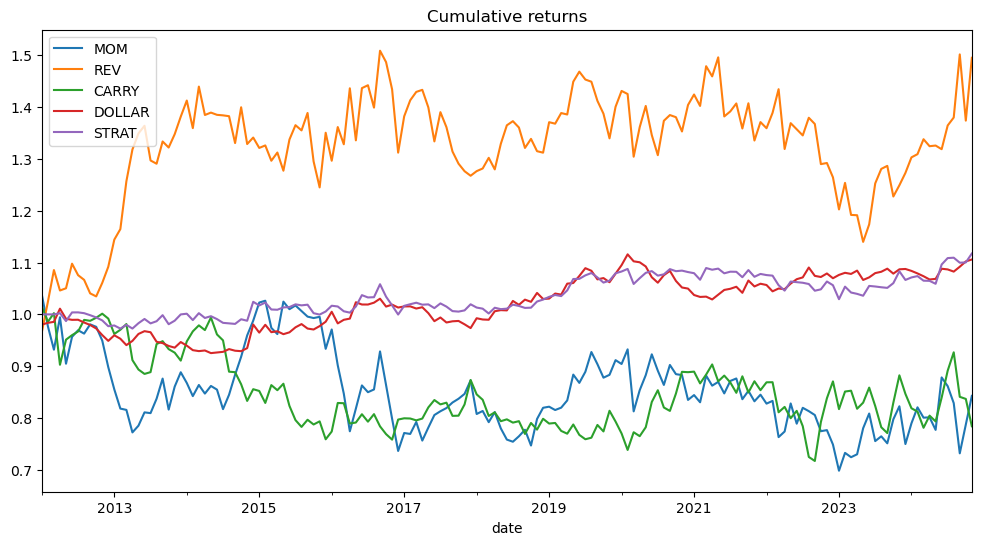

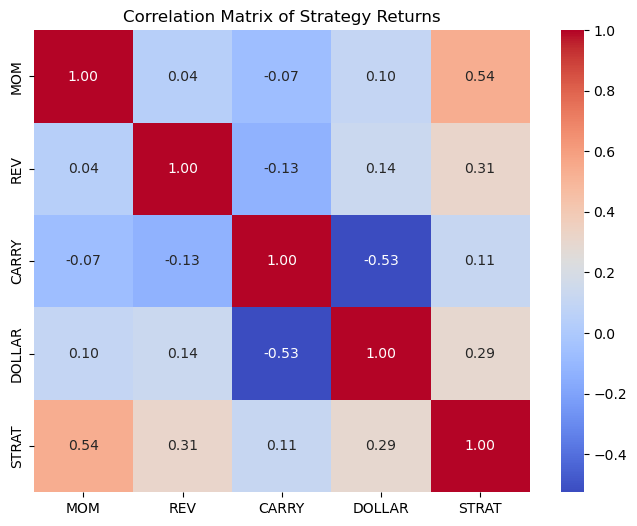

In [256]:

df_q8_2 = df_q8[['MOM', 'REV', 'CARRY', 'DOLLAR']].copy()


window = 60  
rolling_vol = df_q8_2.shift(1).rolling(window=window).std()
inv_vol = 1 / rolling_vol
weights = inv_vol.div(inv_vol.sum(axis=1), axis=0) # Normalized weights (sum to 1)
weights_lagged = weights.shift(1) # Shift so that (t-1) weight apply to return (t) 
R_STRAT = (df_q8_2 * weights_lagged).sum(axis=1) 


print(f"Annualized volatility STRAT : {R_STRAT.std() * np.sqrt(12):.2%}")
print(f"Annualized return STRAT : {R_STRAT.mean() * 12:.2%}")

df_q8_2['STRAT'] = R_STRAT #less data in RSTRAT then in the full dataframe 
df_q8['STRAT'] = R_STRAT

#Plots to understand distribution of weights 
weights_lagged.loc["2012":].plot(title="Dynamic weights in RSTRAT(risk parity)", figsize=(12,6))
print(weights_lagged.mean())

rolling_vol["2017":].plot(title="Dynamic std (60 month rolling window)", figsize=(12,6))

(1 + df_q8_2).loc["2012":].cumprod().plot(title="Cumulative returns", figsize=(12,6))


# Plot correlation
corr_matrix = df_q8_2.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Strategy Returns")
plt.show()

# 8.3 

In [257]:
valid_mask = df_q8['STRAT'] != 0
excess_combined = pd.DataFrame({
    'DIV_EXCESS': df_q8.loc[valid_mask, 'DIV'] - df_q8.loc[valid_mask, 'T_BILL'],
    'STRAT': df_q8.loc[valid_mask, 'STRAT']
})

window = 60 
target_vol = 0.15 

dates = []
b_list = []
c_list = []
T_list = []


for start in range(len(excess_combined) - window):
    window_data = excess_combined.iloc[start:start + window]

    mu = window_data.mean().values * 12
    sigma = window_data.cov().values * 12

    # Inversion of cov matrix
    try:
        sigma_inv = np.linalg.inv(sigma)
    except np.linalg.LinAlgError:
        continue  # to avoid issue if singular matrix

    #mve portfolio classic form 
    x0_1 = sigma_inv @ mu
    x0 = 1/(x0_1.sum())*x0_1
    #scaling to achieve target volatility
    lambda_scaling = target_vol / np.sqrt(x0.T @ sigma @ x0)
    x = lambda_scaling * x0

    b, c = x
    T = 1 -b -c 
    apply_index = excess_combined.index[start + window] 
    dates.append(apply_index)
    b_list.append(b)
    c_list.append(c)
    T_list.append(T)
    

#Keeping results 
results_df = pd.DataFrame({
    "Date": dates,
    "b": b_list,
    "c": c_list,
    "w_tbills" : T_list
})
results_df.set_index("Date", inplace=True)


# Again, we shift to apply correct weights
excess_combined["T_BILL"]=df_q8["T_BILL"]
results_df_shifted=results_df.shift(1).dropna()
excess_combined_short=excess_combined.loc["2017-05-31":]
assert results_df_shifted.index.equals(excess_combined_short.index)
results_df["RFUND_q3"] = excess_combined_short["T_BILL"] + results_df_shifted["b"] * excess_combined_short["DIV_EXCESS"] + results_df_shifted["c"] * excess_combined_short["STRAT"]
results_df=results_df.dropna()
# Affichage de la performance
print("Volatilité annualisée de RFUND_q3 :", results_df["RFUND_q3"].std() * np.sqrt(12))
print("Rendement annualisé de RFUND_q3 :", results_df["RFUND_q3"].mean() * 12)




Volatilité annualisée de RFUND_q3 : 0.16445935732803285
Rendement annualisé de RFUND_q3 : 0.08451314944902456


In [258]:
#compute rfund on each rolling window, check volatility and store weight of each substrategy 
RFUND_vols=[]
weights_by_strategy = {col: [] for col in df_q8_2.columns}

for start in range(len(results_df)):
    window_data = excess_combined.iloc[start:start + window].copy()

    b = results_df["b"].iloc[start]
    c = results_df["c"].iloc[start]

    for i in ["MOM", "REV", "CARRY", "DOLLAR"]:
        date = results_df.index[start]
        weight = c * weights_lagged.loc[date, i]
        weights_by_strategy[i].append(weight)


    r_fund= window_data["T_BILL"]+ b * window_data["DIV_EXCESS"] + c * window_data["STRAT"]
    vol = r_fund.std() * np.sqrt(12)
    RFUND_vols.append(vol)


for i in ["MOM", "REV", "CARRY", "DOLLAR"]:
    results_df[f"{i} weight"] = weights_by_strategy[i]

results_df["sum_component_weights"] = (
    results_df["MOM weight"] +
    results_df["REV weight"] +
    results_df["CARRY weight"] +
    results_df["DOLLAR weight"]
)
#check that sum of weight on substrategies = c 
assert np.allclose(results_df["sum_component_weights"], results_df["c"], atol=1e-5)
results_df["RFUND Volatility"] = RFUND_vols
results_df["RFUND_q1"] = RFUND_q8_1 #to cut R_FUND_q8_1 which is longer 


mean_result=results_df.mean(axis=0).to_frame().T 
mean_result

,b,c,w_tbills,RFUND_q3,MOM weight,REV weight,CARRY weight,DOLLAR weight,sum_component_weights,RFUND Volatility,RFUND_q1
0,0.855421,1.500562,-1.355983,0.007043,0.207462,0.234004,0.300805,0.758291,1.500562,0.149951,0.007797


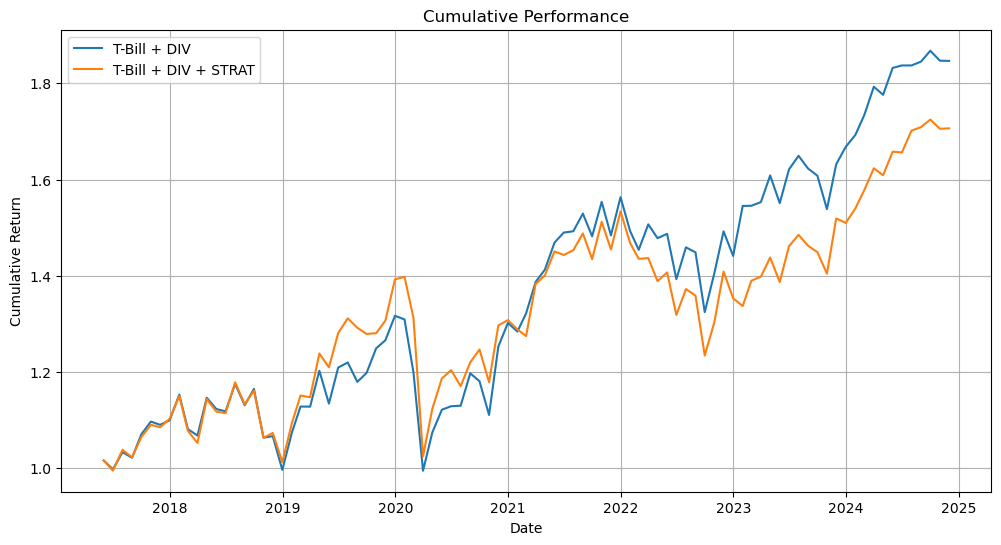


Performance Metrics:
T-Bill + DIV Strategy - Mean: 9.36%, Std Dev: 15.70%, Sharpe Ratio: 0.60
T-Bill + DIV + STRAT Strategy - Mean: 8.45%, Std Dev: 16.45%, Sharpe Ratio: 0.51


In [259]:
#plot cumulative return (starting in 2017)
def cumulative_return(returns):
    return (1+returns).cumprod()
cumulative_rfund_1 = cumulative_return(results_df["RFUND_q1"])
cumulative_rfund_3= cumulative_return(results_df["RFUND_q3"])


plt.figure(figsize=(12, 6))
plt.plot(cumulative_rfund_1, label='T-Bill + DIV ')
plt.plot(cumulative_rfund_3, label='T-Bill + DIV + STRAT')
plt.title('Cumulative Performance')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

# Performance Metrics
def calculate_metrics(returns):
    mean_return = returns.mean() * 12
    std_dev = returns.std() * np.sqrt(12)
    sharpe_ratio = mean_return / std_dev
    return mean_return, std_dev, sharpe_ratio


mean_rfund, std_rfund, sharpe_rfund = calculate_metrics(results_df["RFUND_q1"])
mean_strat, std_strat, sharpe_strat = calculate_metrics(results_df["RFUND_q3"])


print("\nPerformance Metrics:")
print(f"T-Bill + DIV Strategy - Mean: {mean_rfund:.2%}, Std Dev: {std_rfund:.2%}, Sharpe Ratio: {sharpe_rfund:.2f}")
print(f"T-Bill + DIV + STRAT Strategy - Mean: {mean_strat:.2%}, Std Dev: {std_strat:.2%}, Sharpe Ratio: {sharpe_strat:.2f}")

# 9 - Performance and risk analysis for the Fund strategy

In [260]:
def run_ff5_regression(strategy_returns, ff_factors):
    aligned = pd.concat([strategy_returns, ff_factors], axis=1).dropna()
    # Compute excess return of the strategy
    y = aligned.iloc[:, 0].astype(float) - aligned['RF'].astype(float) 
    X = aligned.iloc[:, 1:-1].astype(float)

    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit() 

    print(f"\nRegression Results of {strategy_returns.columns[0]} on Fama-French 5 factor model:")
    print(model.summary())

    alpha = model.params['const']
    pval_alpha = model.pvalues['const']
    r2 = model.rsquared

    print("\nInterpretation:")
    if pval_alpha < 0.05:
        print(f"- Significant alpha ({alpha:.4f}) suggests return not explained by FF5 factors")
    else:
        print(f"- No significant alpha ({alpha:.4f})")

    print(f"- R-squared: {r2:.4f} suggests {'strong' if r2 > 0.5 else 'weak'} explanatory power")

    print("- Factor exposures (t-stats and p-values):")
    for factor in X.columns[1:]:
        beta = model.params[factor]
        tval = model.tvalues[factor]
        pval = model.pvalues[factor]
        if pval < 0.05:
            print(f"  • {factor}: {beta:.4f}, t = {tval:.2f}, p = {pval:.3f} (significant)")
        else:
            print(f"  • {factor}: {beta:.4f}, t = {tval:.2f}, p = {pval:.3f} (not significant)")

    return model


In [261]:
FF_5 = pd.read_csv('data/FamaFrench_Monthly_2002_2024.csv', index_col=0)
FF_5.index = pd.to_datetime(FF_5.index) + MonthEnd(0)
# adapt to the size of the Strat
FF_5 = FF_5.loc[FF_5.index <= '2024-11-30']
FF_5 = FF_5.loc[FF_5.index >= '2017-05-31']
FF_5 = FF_5/100
FF_5

,Mkt-RF,SMB,HML,RMW,CMA,RF
date,,,,,,
2017-05-31,0.0107,-0.0299,-0.0382,0.0099,-0.0166,0.0006
2017-06-30,0.0078,0.0252,0.0150,-0.0226,0.0004,0.0006
2017-07-31,0.0188,-0.0164,-0.0023,-0.0075,-0.0015,0.0007
2017-08-31,0.0018,-0.0183,-0.0213,0.0020,-0.0238,0.0009
2017-09-30,0.0249,0.0476,0.0315,-0.0154,0.0163,0.0009
...,...,...,...,...,...,...
2024-07-31,0.0122,0.0834,0.0562,0.0027,0.0028,0.0045
2024-08-31,0.0161,-0.0355,-0.0110,0.0074,0.0082,0.0048
2024-09-30,0.0173,-0.0092,-0.0277,0.0018,-0.0029,0.0040


In [262]:
model = run_ff5_regression(results_df[['RFUND_q3']].dropna(), FF_5)



Regression Results of RFUND_q3 on Fama-French 5 factor model:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                     31.77
Date:                Sun, 15 Jun 2025   Prob (F-statistic):           4.13e-18
Time:                        23:43:14   Log-Likelihood:                 196.67
No. Observations:                  91   AIC:                            -381.3
Df Residuals:                      85   BIC:                            -366.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------